## Network diameter vs. average shortest path length
This notebook shows how network structure influences **diameter** and **average shortest path length** of a network.
They are first calculated for a random network and then for a random network with an attached linear pathway.

In [1]:
%matplotlib inline
import random
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# set seed to make the simulation reproducible
random.seed(4) 

In [3]:
# create a random network
random_network = nx.fast_gnp_random_graph(300, 0.04)

In [4]:
# draw the network
layout1 = nx.kamada_kawai_layout(random_network)

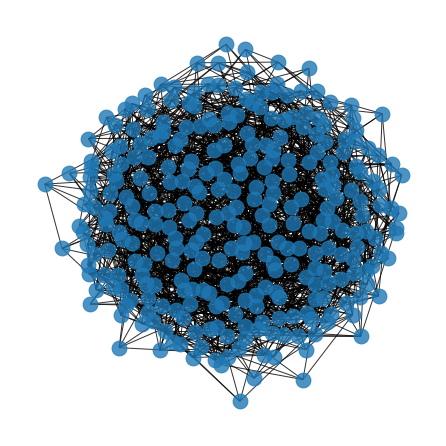

In [5]:
plt.rcParams['figure.figsize'] = [6, 6]
nx.draw(random_network, pos=layout1, node_size = 220, alpha = 0.8)

In [6]:
# calculate average shortest path length and diameter
path_len1 = round(nx.average_shortest_path_length(random_network), 2)
diameter1 = nx.diameter(random_network)

In [7]:
print(f"The average shortest path length is {path_len1}.")
print(f"The diameter of the random network is {diameter1}.")

The average shortest path length is 2.6.
The diameter of the random network is 4.


In [8]:
# make a path graph
path = nx.path_graph(6)
# merge with the random network
network_merged = nx.union(random_network, path, rename=('G1-', 'G2-'))
# connect the two subnetworks with a new edge
network_merged.add_edge("G1-99", "G2-0")

In [9]:
# draw the new network
layout2 = nx.kamada_kawai_layout(network_merged) 

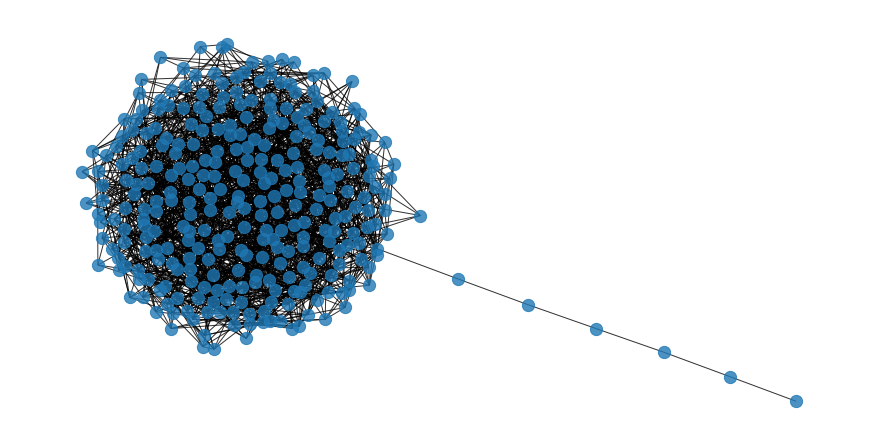

In [10]:
plt.rcParams['figure.figsize'] = [12, 6]
nx.draw(network_merged, pos =layout2, node_size = 150, alpha = 0.8)

In [11]:
# calculate path length and diameter
path_len2 = round(nx.average_shortest_path_length(network_merged), 2)
diameter2 = nx.diameter(network_merged)

In [12]:
print(f"The average shortest path length is {path_len2}.")
print(f"The diameter of the random network + linear pathway is {diameter2}.")

The average shortest path length is 2.73.
The diameter of the random network + linear pathway is 10.


Addition of the linear pathway has only small effect on the average shortest path length but increases the network diameter.

<div class="alert alert-block alert-info">
<b>Note:</b> The code above was for a quick illustration of the two properties. In practice it would be better to run the randomization many times (e.g. 1000 times) and do a statistical test to check if the properties are significantly different. 
</div>
